# Homebound 프로젝트: 가설 검증 EDA

> 문제정의서(v1.0)에서 수립한 **7개 분석 가설**을 데이터 기반으로 검증한다.
> 분석 대상: **개, 고양이** (기타/기타축종 제외) | 기간: 2019~2024년

| 가설 | 내용 | 검증 방법 |
|------|------|----------|
| H1 | 어린 동물일수록 입양률이 높다 | 카이제곱 검정 |
| H2 | 중성화된 동물의 입양률이 유의미하게 높다 | 카이제곱 + Z-검정 |
| H3 | 광역시의 입양률이 도 지역보다 높다 | Mann-Whitney U |
| H4 | 여름철(6~8월) 유기동물 발생 증가, 특히 고양이 | 카이제곱 적합도 |
| H5 | 보호소 규모가 클수록 입양률이 높다 | 스피어만 상관 |
| H6 | 동일 도 내 시군구별 입양률 격차가 크다 | 변동계수(CV) |
| H7 | 연도별 발생 감소 추세, 정책 변곡점 존재 | 선형회귀 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, linregress
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

OUT = '/Users/yu_seok/.claude-squad/worktrees/yu_seok_189f63230615e868/02_outputs'
DATA, FIG = f'{OUT}/data', f'{OUT}/figures'

multidim = pd.read_csv(f'{DATA}/agg_adoption_multidim.csv')
temporal = pd.read_csv(f'{DATA}/agg_temporal_pattern.csv')
region   = pd.read_csv(f'{DATA}/agg_region_yearly.csv')
shelter  = pd.read_csv(f'{DATA}/agg_shelter_performance.csv')

multidim = multidim[multidim['동물종류'].isin(['개','고양이'])]
temporal = temporal[temporal['동물종류'].isin(['개','고양이'])]
region = region[region['접수년도'] <= 2024]
temporal_y = temporal[temporal['접수년도'] <= 2024]

results = []
print(f"multidim: {len(multidim):,}행 | temporal: {len(temporal_y):,}행")
print(f"region: {len(region):,}행 | shelter: {len(shelter):,}행")
print("\n분석 대상: 개·고양이 | 기간: 2019~2024")

multidim: 1,783행 | temporal: 1,008행
region: 102행 | shelter: 564행

분석 대상: 개·고양이 | 기간: 2019~2024


---
## 가설 1: 어린 동물일수록 입양률이 높다
> **예상**: 1세 이하 입양률 > 40%, 8세 이상 < 15%

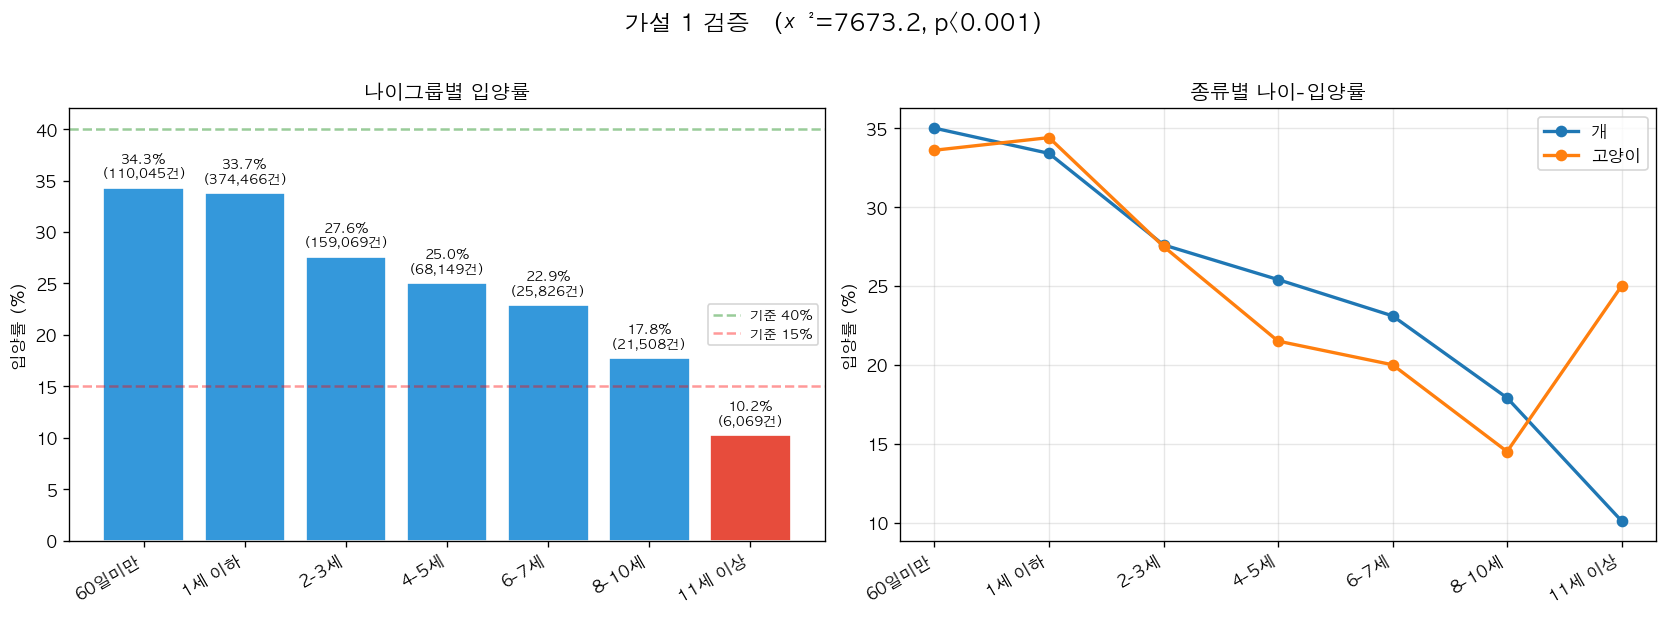

가설 1 검증: 어린 동물일수록 입양률이 높다
  60일미만   :  34.3% ( 110,045건)
  1세 이하   :  33.7% ( 374,466건)
  2-3세    :  27.6% ( 159,069건)
  4-5세    :  25.0% (  68,149건)
  6-7세    :  22.9% (  25,826건)
  8-10세   :  17.8% (  21,508건)
  11세 이상  :  10.2% (   6,069건)

  χ²=7,673.2, df=6, p=0.00e+00
  1세이하>>40%: 33.7% ❌
  8-10세<15%: 17.8% ❌
  11세+<15%: 10.2% ✅

  ▶ 판정: ✅ 채택


In [2]:
age_order = ['60일미만','1세 이하','2-3세','4-5세','6-7세','8-10세','11세 이상']
age = multidim[multidim['나이그룹']!='미상'].groupby('나이그룹').agg(
    총=('총건수','sum'), 입양=('입양건수','sum')).reset_index()
age['입양률'] = (age['입양']/age['총']*100).round(2)
age['비입양'] = age['총'] - age['입양']
age['나이그룹'] = pd.Categorical(age['나이그룹'], age_order, ordered=True)
age = age.sort_values('나이그룹')

chi2, p1, dof, _ = chi2_contingency(age[['입양','비입양']].values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71' if r>=40 else '#e74c3c' if r<15 else '#3498db' for r in age['입양률']]
bars = axes[0].bar(range(len(age)), age['입양률'], color=colors, edgecolor='white')
axes[0].set_xticks(range(len(age)))
axes[0].set_xticklabels(age['나이그룹'], rotation=30, ha='right')
for b, v, n in zip(bars, age['입양률'], age['총']):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}%\n({n:,}건)', ha='center', fontsize=8)
axes[0].axhline(40, color='green', ls='--', alpha=.4, label='기준 40%')
axes[0].axhline(15, color='red', ls='--', alpha=.4, label='기준 15%')
axes[0].set_ylabel('입양률 (%)'); axes[0].set_title('나이그룹별 입양률', fontweight='bold')
axes[0].legend(fontsize=8)

for animal in ['개','고양이']:
    a = multidim[(multidim['동물종류']==animal)&(multidim['나이그룹']!='미상')].groupby('나이그룹').agg(
        총=('총건수','sum'), 입양=('입양건수','sum')).reset_index()
    a['입양률'] = (a['입양']/a['총']*100).round(1)
    a['나이그룹'] = pd.Categorical(a['나이그룹'], age_order, ordered=True)
    a = a.sort_values('나이그룹')
    axes[1].plot(range(len(a)), a['입양률'], 'o-', label=animal, lw=2, ms=6)
axes[1].set_xticks(range(len(age_order))); axes[1].set_xticklabels(age_order, rotation=30, ha='right')
axes[1].set_ylabel('입양률 (%)'); axes[1].set_title('종류별 나이-입양률', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=.3)

fig.suptitle(f'가설 1 검증   (χ²={chi2:.1f}, p<0.001)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{FIG}/가설1_나이별입양률.png', bbox_inches='tight'); plt.show()

young = age[age['나이그룹']=='1세 이하']['입양률'].values[0]
r8 = age[age['나이그룹']=='8-10세']['입양률'].values[0]
r11 = age[age['나이그룹']=='11세 이상']['입양률'].values[0]
print("="*65)
print("가설 1 검증: 어린 동물일수록 입양률이 높다")
print("="*65)
for _, row in age.iterrows():
    print(f"  {row['나이그룹']:8s}: {row['입양률']:5.1f}% ({row['총']:>8,}건)")
print(f"\n  χ²={chi2:,.1f}, df={dof}, p={p1:.2e}")
print(f"  1세이하>{'>'}40%: {young:.1f}% {'✅' if young>40 else '❌'}")
print(f"  8-10세<15%: {r8:.1f}% {'✅' if r8<15 else '❌'}")
print(f"  11세+<15%: {r11:.1f}% {'✅' if r11<15 else '❌'}")
verdict = '✅ 채택' if p1<0.05 and young>r11 else '❌ 기각'
print(f"\n  ▶ 판정: {verdict}")
results.append(dict(가설='H1: 어린 동물 → 입양률↑', 판정=verdict, p=f'{p1:.2e}',
                    핵심=f'1세이하 {young:.1f}%, 11세+ {r11:.1f}%'))

---
## 가설 2: 중성화된 동물의 입양률이 유의미하게 높다
> **예상**: 중성화 O가 X 대비 10%p 이상 높음

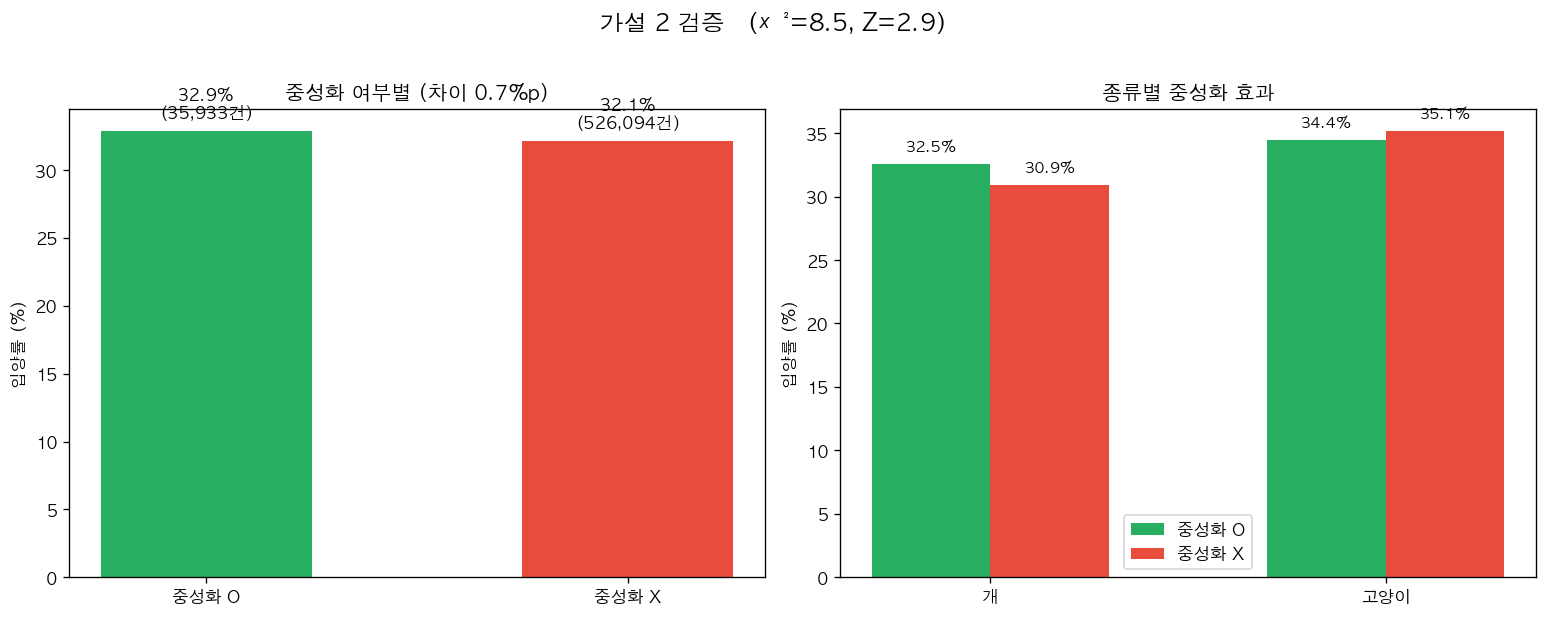

가설 2 검증: 중성화된 동물의 입양률이 유의미하게 높다
  전체: O 32.9% vs X 32.1% (차이 0.7%p)
  개: O 32.5% vs X 30.9% (차이 1.6%p)
  고양이: O 34.4% vs X 35.1% (차이 -0.7%p)

  χ²=8.5, p=3.61e-03 | Z=2.91
  차이 ≥10%p: 0.7%p → ❌

  ▶ 판정: ⚠️ 수정채택


In [3]:
neuter = multidim[multidim['중성화 여부']!='미상'].groupby(['동물종류','중성화 여부']).agg(
    총=('총건수','sum'), 입양=('입양건수','sum')).reset_index()
neuter['입양률'] = (neuter['입양']/neuter['총']*100).round(2)

tot = neuter.groupby('중성화 여부').agg(총=('총','sum'), 입양=('입양','sum')).reset_index()
tot['입양률'] = (tot['입양']/tot['총']*100).round(2)
tot['비입양'] = tot['총'] - tot['입양']
chi2_n, p2, _, _ = chi2_contingency(tot[['입양','비입양']].values)

p_o = tot[tot['중성화 여부']=='중성화 O']
p_x = tot[tot['중성화 여부']=='중성화 X']
rate_o, rate_x = p_o['입양률'].values[0], p_x['입양률'].values[0]
n_o, n_x = p_o['총'].values[0], p_x['총'].values[0]
pp = (p_o['입양'].values[0]+p_x['입양'].values[0])/(n_o+n_x)
se = np.sqrt(pp*(1-pp)*(1/n_o+1/n_x))
z_val = (rate_o/100 - rate_x/100)/se
diff = rate_o - rate_x

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].bar(['중성화 O','중성화 X'], [rate_o, rate_x], color=['#27ae60','#e74c3c'], width=.5)
for b, v, n in zip(bars, [rate_o, rate_x], [n_o, n_x]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}%\n({n:,}건)', ha='center', fontsize=10)
axes[0].set_ylabel('입양률 (%)'); axes[0].set_title(f'중성화 여부별 (차이 {diff:.1f}%p)', fontweight='bold')

animals = ['개','고양이']; xp = np.arange(len(animals)); w=.3
for i, ns in enumerate(['중성화 O','중성화 X']):
    s = neuter[neuter['중성화 여부']==ns]
    vals = [s[s['동물종류']==a]['입양률'].values[0] for a in animals]
    bs = axes[1].bar(xp+(i-.5)*w, vals, w, label=ns, color=['#27ae60','#e74c3c'][i])
    for b, v in zip(bs, vals):
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set_xticks(xp); axes[1].set_xticklabels(animals)
axes[1].set_ylabel('입양률 (%)'); axes[1].set_title('종류별 중성화 효과', fontweight='bold'); axes[1].legend()

fig.suptitle(f'가설 2 검증   (χ²={chi2_n:.1f}, Z={z_val:.1f})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{FIG}/가설2_중성화별입양률.png', bbox_inches='tight'); plt.show()

print("="*65)
print("가설 2 검증: 중성화된 동물의 입양률이 유의미하게 높다")
print("="*65)
print(f"  전체: O {rate_o:.1f}% vs X {rate_x:.1f}% (차이 {diff:.1f}%p)")
for a in animals:
    s = neuter[neuter['동물종류']==a]
    o = s[s['중성화 여부']=='중성화 O']['입양률'].values[0]
    x = s[s['중성화 여부']=='중성화 X']['입양률'].values[0]
    print(f"  {a}: O {o:.1f}% vs X {x:.1f}% (차이 {o-x:.1f}%p)")
print(f"\n  χ²={chi2_n:,.1f}, p={p2:.2e} | Z={z_val:.2f}")
print(f"  차이 ≥10%p: {diff:.1f}%p → {'✅' if diff>=10 else '❌'}")
verdict = '✅ 채택' if p2<0.05 and diff>=10 else ('⚠️ 수정채택' if p2<0.05 and diff>0 else '❌ 기각')
print(f"\n  ▶ 판정: {verdict}")
results.append(dict(가설='H2: 중성화 → 입양률↑', 판정=verdict, p=f'{p2:.2e}', 핵심=f'차이 {diff:.1f}%p'))

---
## 가설 3: 광역시의 입양률이 도(군 단위) 지역보다 높다
> **예상**: 광역시 > 도 5~10%p 차이

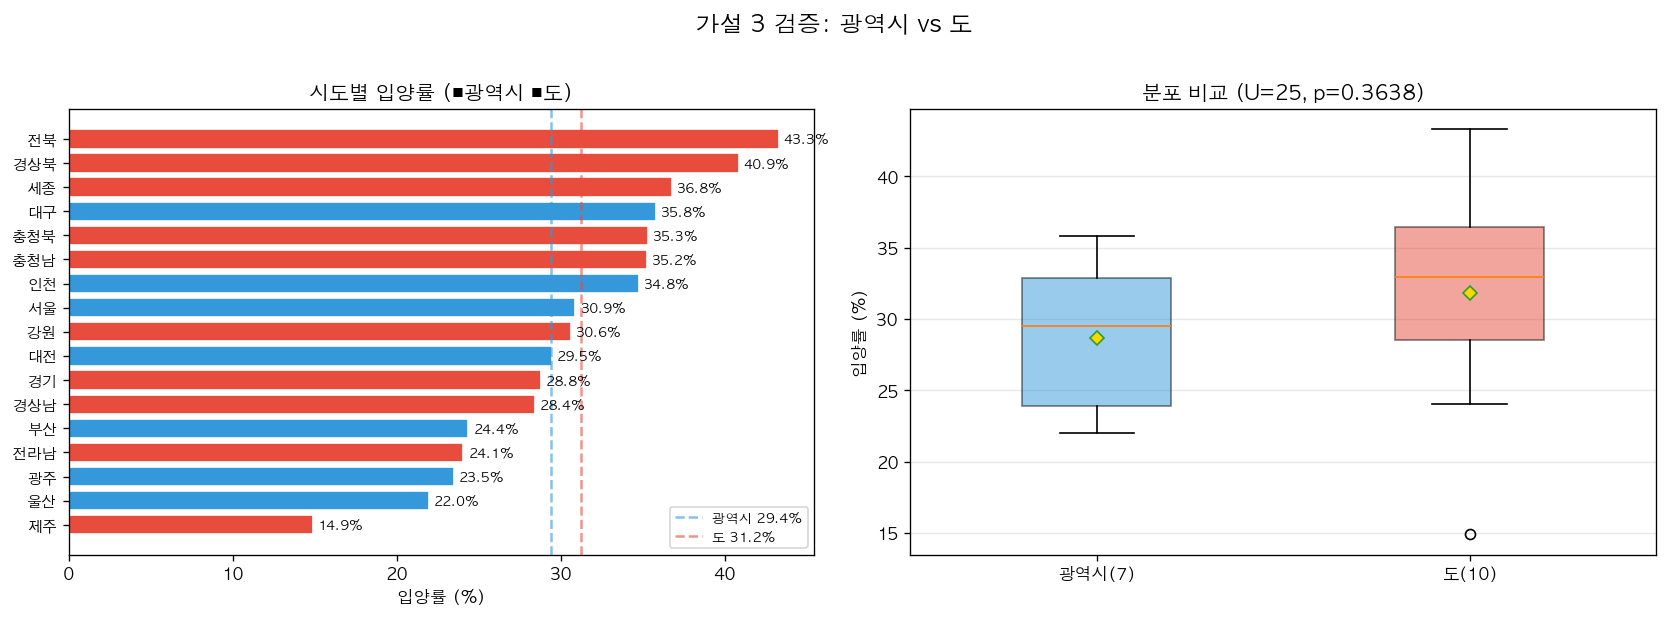

가설 3 검증: 광역시 입양률 > 도 입양률

  [광역시]
    대구  : 35.8% ( 31,608건)
    인천  : 34.8% ( 39,689건)
    서울  : 30.9% ( 34,965건)
    대전  : 29.5% ( 15,122건)
    부산  : 24.4% ( 38,814건)
    광주  : 23.5% ( 20,685건)
    울산  : 22.0% ( 20,118건)
    가중평균: 29.4%

  [도]
    전북  : 43.3% ( 55,753건)
    경상북 : 40.9% ( 59,591건)
    세종  : 36.8% (  3,211건)
    충청북 : 35.3% ( 29,795건)
    충청남 : 35.2% ( 55,733건)
    강원  : 30.6% ( 35,092건)
    경기  : 28.8% (156,054건)
    경상남 : 28.4% ( 76,791건)
    전라남 : 24.1% ( 57,875건)
    제주  : 14.9% ( 34,595건)
    가중평균: 31.2%

  차이: -1.8%p | U=25, p=0.3638

  ▶ 판정: ❌ 기각 (유의하지 않음)


In [4]:
sido = multidim.groupby('시도').agg(총=('총건수','sum'), 입양=('입양건수','sum')).reset_index()
sido['입양률'] = (sido['입양']/sido['총']*100).round(2)
metro_list = ['서울특별시','부산광역시','대구광역시','인천광역시','광주광역시','대전광역시','울산광역시']
sido['유형'] = sido['시도'].apply(lambda x: '광역시' if x in metro_list else '도')

m_rates = sido[sido['유형']=='광역시']['입양률'].values
d_rates = sido[sido['유형']=='도']['입양률'].values
u_stat, p3 = mannwhitneyu(m_rates, d_rates, alternative='two-sided')

m_grp = sido[sido['유형']=='광역시']; d_grp = sido[sido['유형']=='도']
m_avg = m_grp['입양'].sum()/m_grp['총'].sum()*100
d_avg = d_grp['입양'].sum()/d_grp['총'].sum()*100
diff3 = m_avg - d_avg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sido_s = sido.sort_values('입양률')
colors = ['#e74c3c' if t=='도' else '#3498db' for t in sido_s['유형']]
short = lambda s: s.replace('특별자치도','').replace('특별자치시','').replace('광역시','').replace('특별시','').replace('도','')
bars = axes[0].barh(range(len(sido_s)), sido_s['입양률'], color=colors, edgecolor='white')
axes[0].set_yticks(range(len(sido_s))); axes[0].set_yticklabels([short(s) for s in sido_s['시도']], fontsize=9)
for b, v in zip(bars, sido_s['입양률']):
    axes[0].text(b.get_width()+.3, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)
axes[0].axvline(m_avg, color='#3498db', ls='--', alpha=.6, label=f'광역시 {m_avg:.1f}%')
axes[0].axvline(d_avg, color='#e74c3c', ls='--', alpha=.6, label=f'도 {d_avg:.1f}%')
axes[0].set_xlabel('입양률 (%)'); axes[0].set_title('시도별 입양률 (■광역시 ■도)', fontweight='bold')
axes[0].legend(fontsize=8)

bp = axes[1].boxplot([m_rates, d_rates], labels=['광역시(7)','도(10)'], patch_artist=True, widths=.4, showmeans=True,
                     meanprops=dict(marker='D',markerfacecolor='gold'))
bp['boxes'][0].set_facecolor('#3498db'); bp['boxes'][1].set_facecolor('#e74c3c')
for b in bp['boxes']: b.set_alpha(.5)
axes[1].set_ylabel('입양률 (%)'); axes[1].set_title(f'분포 비교 (U={u_stat:.0f}, p={p3:.4f})', fontweight='bold')
axes[1].grid(alpha=.3, axis='y')

fig.suptitle('가설 3 검증: 광역시 vs 도', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{FIG}/가설3_광역시vs도.png', bbox_inches='tight'); plt.show()

print("="*65)
print("가설 3 검증: 광역시 입양률 > 도 입양률")
print("="*65)
print("\n  [광역시]")
for _, r in sido[sido['유형']=='광역시'].sort_values('입양률', ascending=False).iterrows():
    print(f"    {short(r['시도']):4s}: {r['입양률']:.1f}% ({r['총']:>7,}건)")
print(f"    가중평균: {m_avg:.1f}%")
print("\n  [도]")
for _, r in sido[sido['유형']=='도'].sort_values('입양률', ascending=False).iterrows():
    print(f"    {short(r['시도']):4s}: {r['입양률']:.1f}% ({r['총']:>7,}건)")
print(f"    가중평균: {d_avg:.1f}%")
print(f"\n  차이: {diff3:+.1f}%p | U={u_stat:.0f}, p={p3:.4f}")
if p3<0.05 and diff3>0: verdict='✅ 채택'
elif p3>=0.05: verdict='❌ 기각 (유의하지 않음)'
else: verdict='❌ 기각 (방향 반대)'
print(f"\n  ▶ 판정: {verdict}")
results.append(dict(가설='H3: 광역시 > 도', 판정=verdict, p=f'{p3:.4f}', 핵심=f'차이 {diff3:+.1f}%p'))

---
## 가설 4: 여름철(6~8월) 유기동물 발생 증가, 특히 고양이
> **예상**: 고양이 6~8월 발생이 월평균 대비 30% 이상 높음

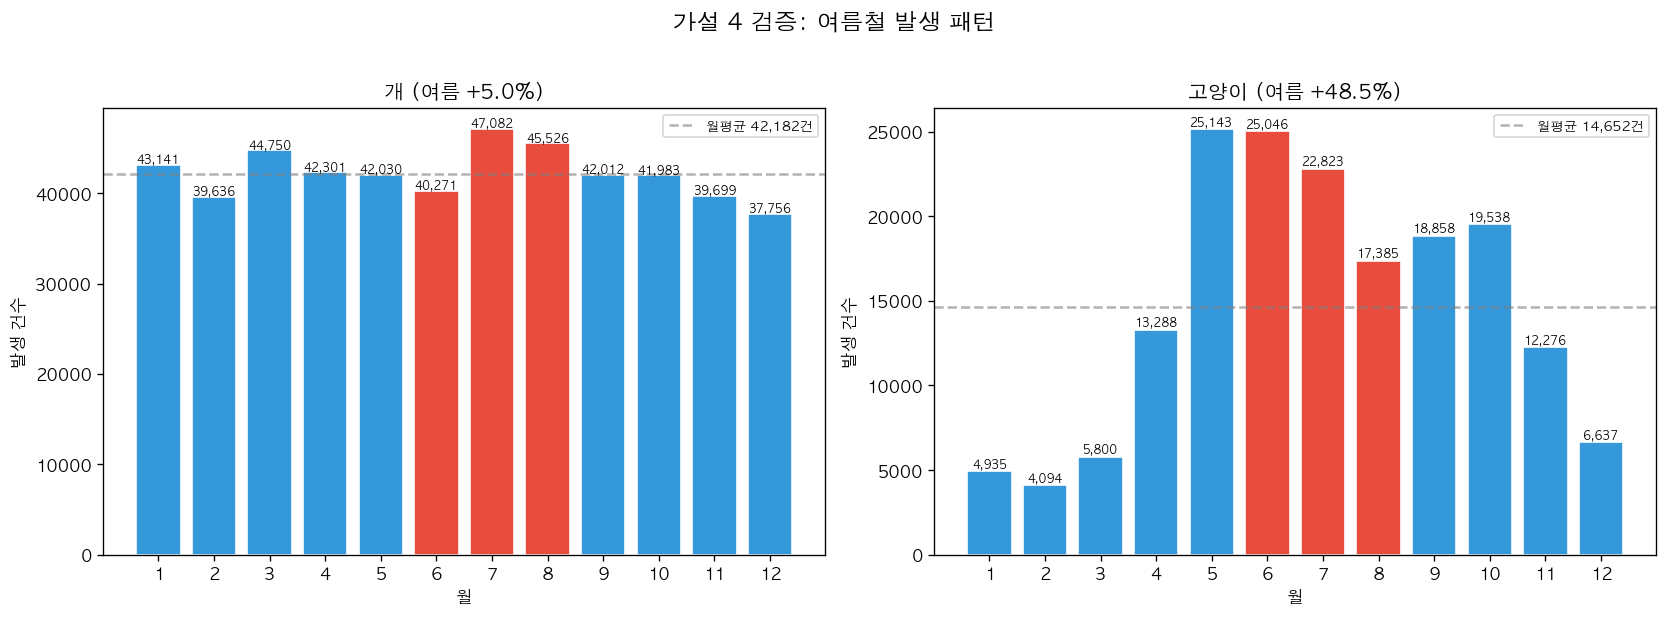

가설 4 검증: 여름철 유기동물 발생 증가

  [개] 월평균 대비 여름: +5.0%
    적합도 검정: χ²=1,865.7, p=0.00e+00 → 균등분포 기각

  [고양이] 월평균 대비 여름: +48.5%
    적합도 검정: χ²=47,085.3, p=0.00e+00 → 균등분포 기각

  예상: 고양이 ≥30% → +48.5% ✅
  고양이(48.5%) vs 개(5.0%): 고양이가 더 집중

  ▶ 판정: ✅ 채택


In [5]:
monthly = temporal_y.groupby(['접수월','동물종류'])['총건수'].sum().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summer_ratios = {}
for idx, animal in enumerate(['개','고양이']):
    sub = monthly[monthly['동물종류']==animal].sort_values('접수월')
    avg = sub['총건수'].mean()
    s_avg = sub[sub['접수월'].isin([6,7,8])]['총건수'].mean()
    summer_ratios[animal] = (s_avg/avg - 1)*100

    cols = ['#e74c3c' if m in [6,7,8] else '#3498db' for m in sub['접수월']]
    bars = axes[idx].bar(sub['접수월'], sub['총건수'], color=cols, edgecolor='white')
    axes[idx].axhline(avg, color='gray', ls='--', alpha=.6, label=f'월평균 {avg:,.0f}건')
    for b, n in zip(bars, sub['총건수']):
        axes[idx].text(b.get_x()+b.get_width()/2, b.get_height()+200, f'{n:,}', ha='center', fontsize=7)
    axes[idx].set_xlabel('월'); axes[idx].set_ylabel('발생 건수')
    axes[idx].set_title(f'{animal} (여름 +{summer_ratios[animal]:.1f}%)', fontweight='bold')
    axes[idx].set_xticks(range(1,13)); axes[idx].legend(fontsize=8)

fig.suptitle('가설 4 검증: 여름철 발생 패턴', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{FIG}/가설4_여름철발생.png', bbox_inches='tight'); plt.show()

print("="*65)
print("가설 4 검증: 여름철 유기동물 발생 증가")
print("="*65)
for animal in ['개','고양이']:
    sub = monthly[monthly['동물종류']==animal].sort_values('접수월')
    obs = sub['총건수'].values
    exp = np.full(12, obs.sum()/12)
    chi2_s, p_s = stats.chisquare(obs, exp)
    print(f"\n  [{animal}] 월평균 대비 여름: +{summer_ratios[animal]:.1f}%")
    print(f"    적합도 검정: χ²={chi2_s:,.1f}, p={p_s:.2e} → {'균등분포 기각' if p_s<0.05 else '균등'}")

cat_r = summer_ratios['고양이']; dog_r = summer_ratios['개']
print(f"\n  예상: 고양이 ≥30% → +{cat_r:.1f}% {'✅' if cat_r>=30 else '❌'}")
print(f"  고양이({cat_r:.1f}%) vs 개({dog_r:.1f}%): 고양이가 {'더 집중' if cat_r>dog_r else '덜 집중'}")
verdict = '✅ 채택' if cat_r>=30 else ('⚠️ 수정채택' if cat_r>=15 else '❌ 기각')
print(f"\n  ▶ 판정: {verdict}")
results.append(dict(가설='H4: 여름 발생↑ 고양이', 판정=verdict, p=f'{p_s:.2e}',
                    핵심=f'고양이 +{cat_r:.1f}%, 개 +{dog_r:.1f}%'))

---
## 가설 5: 보호소 규모(총 보호건수)가 클수록 입양률이 높다
> **예상**: 상관계수 > 0.3

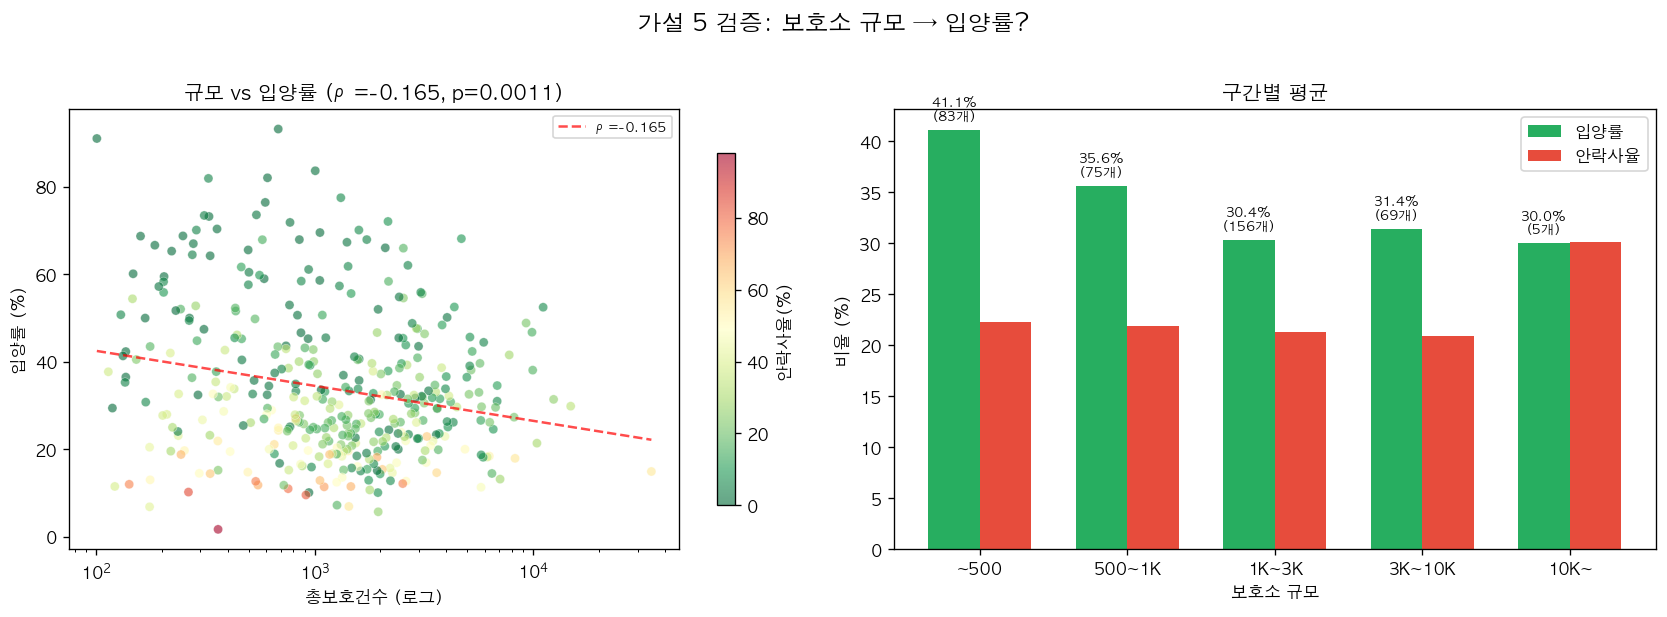

가설 5 검증: 보호소 규모↑ → 입양률↑
  분석: 388개 보호소 (100건+)
  Spearman ρ=-0.165, p=0.0011
  ~500    : 입양 41.1%, 안락사 22.3% (83개)
  500~1K  : 입양 35.6%, 안락사 21.9% (75개)
  1K~3K   : 입양 30.4%, 안락사 21.3% (156개)
  3K~10K  : 입양 31.4%, 안락사 21.0% (69개)
  10K~    : 입양 30.0%, 안락사 30.1% (5개)

  예상: ρ>0.3 → -0.165 ❌

  ▶ 판정: ❌ 기각 (방향 반대: 규모↑→입양률↓)
  ▶ 해석: 대형 보호소 = 수용 과부하 → 개별 관리 한계 → 안락사 증가


In [6]:
sh = shelter[shelter['총보호건수']>=100].copy()
sh['로그규모'] = np.log10(sh['총보호건수'])
rho, p5 = spearmanr(sh['총보호건수'], sh['입양률'])

sh['규모'] = pd.cut(sh['총보호건수'], bins=[0,500,1000,3000,10000,50000],
                    labels=['~500','500~1K','1K~3K','3K~10K','10K~'])
sg = sh.groupby('규모', observed=True).agg(
    수=('보호소명','count'), 입양률=('입양률','mean'), 안락사율=('안락사율','mean')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(sh['총보호건수'], sh['입양률'], c=sh['안락사율'], cmap='RdYlGn_r',
                     s=30, alpha=.6, edgecolor='white', lw=.3)
plt.colorbar(sc, ax=axes[0], label='안락사율(%)', shrink=.8)
z = np.polyfit(sh['로그규모'], sh['입양률'], 1)
xl = np.linspace(sh['로그규모'].min(), sh['로그규모'].max(), 100)
axes[0].plot(10**xl, np.polyval(z, xl), 'r--', alpha=.7, label=f'ρ={rho:.3f}')
axes[0].set_xscale('log'); axes[0].set_xlabel('총보호건수 (로그)'); axes[0].set_ylabel('입양률 (%)')
axes[0].set_title(f'규모 vs 입양률 (ρ={rho:.3f}, p={p5:.4f})', fontweight='bold'); axes[0].legend(fontsize=8)

xp = range(len(sg)); w=.35
axes[1].bar([p-w/2 for p in xp], sg['입양률'], w, label='입양률', color='#27ae60')
axes[1].bar([p+w/2 for p in xp], sg['안락사율'], w, label='안락사율', color='#e74c3c')
axes[1].set_xticks(xp); axes[1].set_xticklabels(sg['규모'])
for b, v, n in zip(axes[1].patches[:len(sg)], sg['입양률'], sg['수']):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}%\n({n}개)', ha='center', fontsize=8)
axes[1].set_xlabel('보호소 규모'); axes[1].set_ylabel('비율 (%)'); axes[1].set_title('구간별 평균', fontweight='bold')
axes[1].legend()

fig.suptitle('가설 5 검증: 보호소 규모 → 입양률?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{FIG}/가설5_보호소규모.png', bbox_inches='tight'); plt.show()

print("="*65)
print("가설 5 검증: 보호소 규모↑ → 입양률↑")
print("="*65)
print(f"  분석: {len(sh)}개 보호소 (100건+)")
print(f"  Spearman ρ={rho:.3f}, p={p5:.4f}")
for _, r in sg.iterrows():
    print(f"  {r['규모']:8s}: 입양 {r['입양률']:.1f}%, 안락사 {r['안락사율']:.1f}% ({int(r['수'])}개)")
print(f"\n  예상: ρ>0.3 → {rho:.3f} {'✅' if rho>0.3 else '❌'}")
if rho<0 and p5<0.05: verdict='❌ 기각 (방향 반대: 규모↑→입양률↓)'
elif rho>0 and p5<0.05: verdict='✅ 채택'
else: verdict='❌ 기각'
print(f"\n  ▶ 판정: {verdict}")
if rho<0:
    print("  ▶ 해석: 대형 보호소 = 수용 과부하 → 개별 관리 한계 → 안락사 증가")
results.append(dict(가설='H5: 규모↑→입양률↑', 판정=verdict, p=f'{p5:.4f}', 핵심=f'ρ={rho:.3f}'))

---
## 가설 6: 동일 도 내에서도 시군구별 입양률 격차가 크다
> **예상**: 변동계수 > 0.3, 최고-최저 격차 30%p 이상

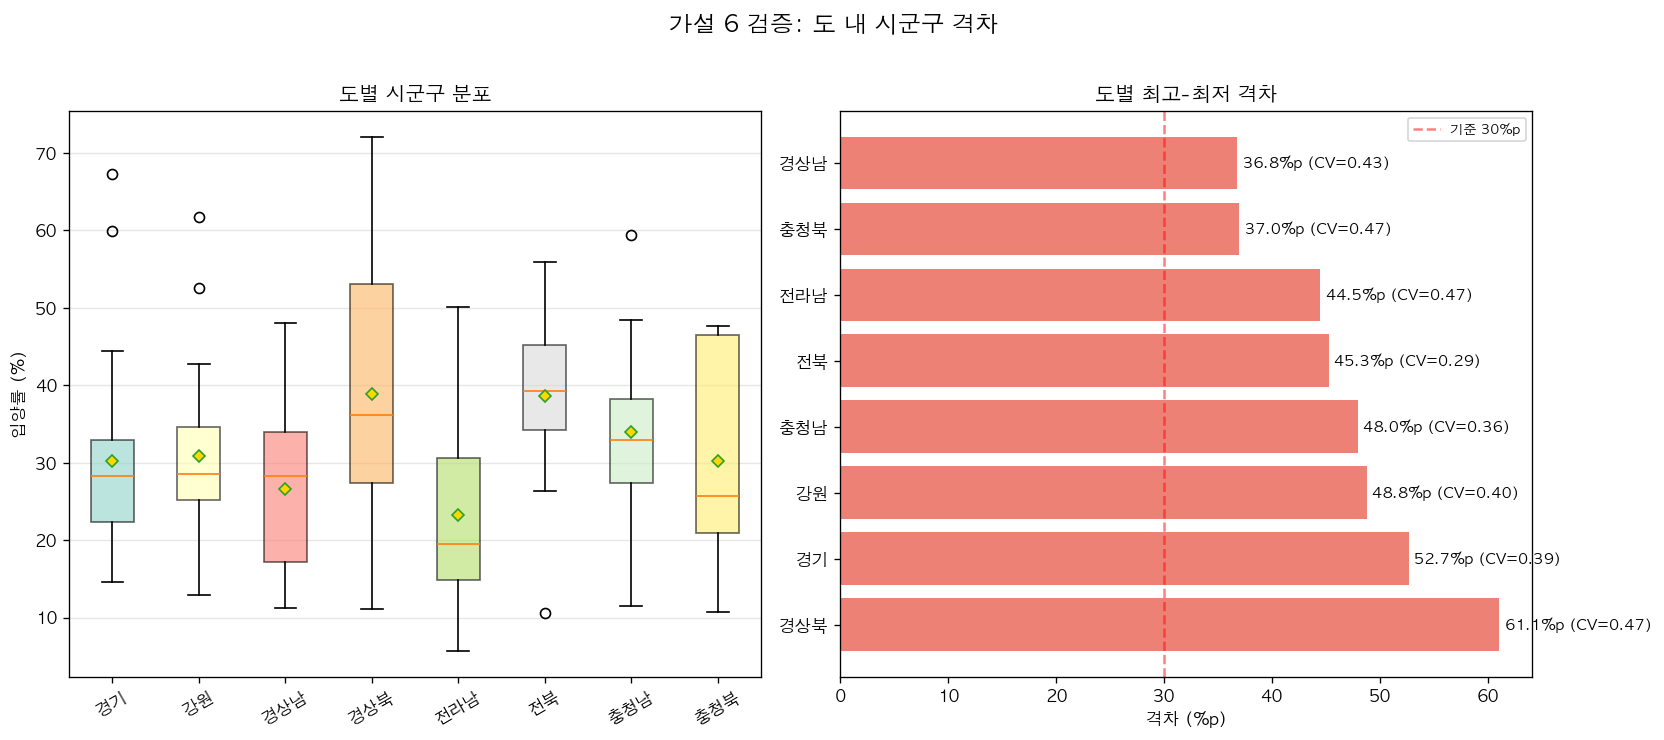

가설 6 검증: 동일 도 내 시군구별 격차

  [경상북] 시군구 22개
    CV=0.465, 격차=61.1%p
    최고: 칠곡군(72.1%) / 최저: 청송군(11.0%)

  [경기] 시군구 31개
    CV=0.385, 격차=52.7%p
    최고: 가평군(67.3%) / 최저: 연천군(14.6%)

  [강원] 시군구 18개
    CV=0.399, 격차=48.8%p
    최고: 평창군(61.7%) / 최저: 횡성군(12.9%)

  [충청남] 시군구 15개
    CV=0.358, 격차=48.0%p
    최고: 아산시(59.5%) / 최저: 서천군(11.5%)

  [전북] 시군구 14개
    CV=0.294, 격차=45.3%p
    최고: 김제시(55.9%) / 최저: 고창군(10.6%)

  [전라남] 시군구 22개
    CV=0.472, 격차=44.5%p
    최고: 여수시(50.2%) / 최저: 완도군(5.7%)

  [충청북] 시군구 11개
    CV=0.467, 격차=37.0%p
    최고: 충주시(47.6%) / 최저: 영동군(10.7%)

  [경상남] 시군구 18개
    CV=0.427, 격차=36.8%p
    최고: 고성군(48.1%) / 최저: 창녕군(11.3%)

  평균 CV: 0.408 | 평균 격차: 46.8%p
  CV>0.3: 7/8 | 격차>30%p: 8/8

  ▶ 판정: ✅ 채택
  ▶ 광역 공동 보호체계의 필요성을 강하게 시사


In [7]:
city = shelter.groupby(['시도','시군구']).agg(
    총=('총보호건수','sum'), 입양=('입양건수','sum')).reset_index()
city['입양률'] = (city['입양']/city['총']*100).round(2)

도s = ['경기도','강원특별자치도','경상남도','경상북도','전라남도','전북특별자치도','충청남도','충청북도']
city_do = city[city['시도'].isin(도s)]
short_do = lambda d: d.replace('특별자치도','').replace('특별자치시','').replace('도','')

gaps = []
for do in 도s:
    s = city_do[city_do['시도']==do]
    if len(s)<2: continue
    cv = s['입양률'].std()/s['입양률'].mean()
    gap = s['입양률'].max()-s['입양률'].min()
    top = s.nlargest(1,'입양률').iloc[0]; bot = s.nsmallest(1,'입양률').iloc[0]
    gaps.append(dict(시도=do, CV=round(cv,3), 격차=round(gap,1),
                     최고=f"{top['시군구']}({top['입양률']:.1f}%)", 최저=f"{bot['시군구']}({bot['입양률']:.1f}%)", n=len(s)))
gdf = pd.DataFrame(gaps).sort_values('격차', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
data_box = [city_do[city_do['시도']==d]['입양률'].values for d in 도s]
bp = axes[0].boxplot(data_box, labels=[short_do(d) for d in 도s], patch_artist=True, showmeans=True,
                     meanprops=dict(marker='D',markerfacecolor='gold',markersize=5))
for patch, c in zip(bp['boxes'], plt.cm.Set3(np.linspace(0,1,len(도s)))):
    patch.set_facecolor(c); patch.set_alpha(.6)
axes[0].set_ylabel('입양률 (%)'); axes[0].set_title('도별 시군구 분포', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30); axes[0].grid(alpha=.3, axis='y')

bars = axes[1].barh(range(len(gdf)), gdf['격차'], color='#e74c3c', alpha=.7)
axes[1].set_yticks(range(len(gdf))); axes[1].set_yticklabels([short_do(d) for d in gdf['시도']])
for b, cv, g in zip(bars, gdf['CV'], gdf['격차']):
    axes[1].text(b.get_width()+.5, b.get_y()+b.get_height()/2, f'{g:.1f}%p (CV={cv:.2f})', va='center', fontsize=9)
axes[1].axvline(30, color='red', ls='--', alpha=.5, label='기준 30%p'); axes[1].legend(fontsize=8)
axes[1].set_xlabel('격차 (%p)'); axes[1].set_title('도별 최고-최저 격차', fontweight='bold')

fig.suptitle('가설 6 검증: 도 내 시군구 격차', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{FIG}/가설6_도내격차.png', bbox_inches='tight'); plt.show()

print("="*65)
print("가설 6 검증: 동일 도 내 시군구별 격차")
print("="*65)
for _, r in gdf.iterrows():
    print(f"\n  [{short_do(r['시도'])}] 시군구 {r['n']}개")
    print(f"    CV={r['CV']:.3f}, 격차={r['격차']:.1f}%p")
    print(f"    최고: {r['최고']} / 최저: {r['최저']}")
avg_cv = gdf['CV'].mean(); avg_gap = gdf['격차'].mean()
ov_cv = (gdf['CV']>0.3).sum(); ov_gap = (gdf['격차']>30).sum()
print(f"\n  평균 CV: {avg_cv:.3f} | 평균 격차: {avg_gap:.1f}%p")
print(f"  CV>0.3: {ov_cv}/{len(gdf)} | 격차>30%p: {ov_gap}/{len(gdf)}")
verdict = '✅ 채택' if ov_gap>=len(gdf)//2 else '⚠️ 수정채택'
print(f"\n  ▶ 판정: {verdict}")
print("  ▶ 광역 공동 보호체계의 필요성을 강하게 시사")
results.append(dict(가설='H6: 도 내 격차 극심', 판정=verdict, p='-',
                    핵심=f'평균CV {avg_cv:.3f}, 격차 {avg_gap:.1f}%p'))

---
## 가설 7: 연도별 발생 감소 추세, 정책 변곡점 존재
> **예상**: 2021~2022년(동물보호법 개정) 전후 감소 기울기 변화

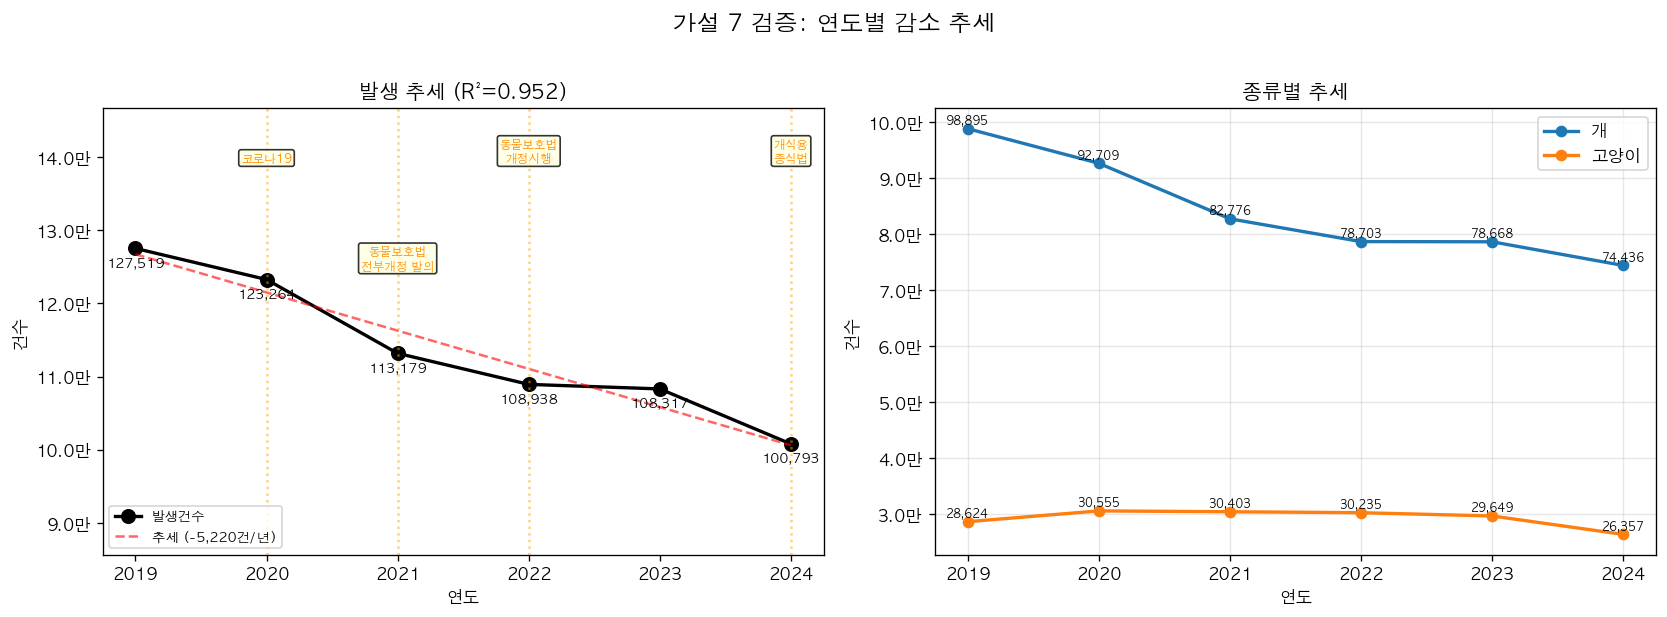

가설 7 검증: 연도별 발생 감소 추세
  2019: 127,519.0건
  2020: 123,264.0건 (-3.3%)
  2021: 113,179.0건 (-8.2%)
  2022: 108,938.0건 (-3.7%)
  2023: 108,317.0건 (-0.6%)
  2024: 100,793.0건 (-6.9%)

  총 감소율: -21.0% | 기울기: -5,220건/년 | R²=0.952, p=0.0009
  전반(19-21): -7,170건/년 | 후반(22-24): -4,072건/년
  → 후반부 감소가 둔화

  ▶ 판정: ✅ 채택


In [8]:
yearly = temporal_y.groupby('접수년도').agg(총=('총건수','sum'), 입양=('입양건수','sum')).reset_index()
yearly['입양률'] = (yearly['입양']/yearly['총']*100).round(2)
yearly_by = temporal_y.groupby(['접수년도','동물종류'])['총건수'].sum().reset_index()

sl, ic, rv, p7, se = linregress(yearly['접수년도'], yearly['총'])
sl_e, _, _, pe, _ = linregress(yearly[yearly['접수년도']<=2021]['접수년도'], yearly[yearly['접수년도']<=2021]['총'])
sl_l, _, _, pl, _ = linregress(yearly[yearly['접수년도']>=2022]['접수년도'], yearly[yearly['접수년도']>=2022]['총'])

policies = {2020:'코로나19', 2021:'동물보호법\n전부개정 발의', 2022:'동물보호법\n개정시행', 2024:'개식용\n종식법'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(yearly['접수년도'], yearly['총'], 'ko-', lw=2, ms=8, label='발생건수')
xf = np.array(yearly['접수년도'])
axes[0].plot(xf, sl*xf+ic, 'r--', alpha=.6, label=f'추세 ({sl:,.0f}건/년)')
for x, y in zip(yearly['접수년도'], yearly['총']):
    axes[0].text(x, y-2500, f'{y:,}', ha='center', fontsize=8, fontweight='bold')
y_max = yearly['총'].max()*1.15
for yr, txt in policies.items():
    axes[0].axvline(yr, color='orange', ls=':', alpha=.5)
    axes[0].text(yr, y_max*(0.95 if yr%2==0 else 0.85), txt, ha='center', fontsize=7, color='darkorange',
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=.8))
axes[0].set_ylim(yearly['총'].min()*0.85, y_max)
axes[0].set_xlabel('연도'); axes[0].set_ylabel('건수')
axes[0].set_title(f'발생 추세 (R²={rv**2:.3f})', fontweight='bold')
axes[0].set_xticks(range(2019,2025))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/10000:.1f}만'))
axes[0].legend(fontsize=8)

for animal in ['개','고양이']:
    s = yearly_by[yearly_by['동물종류']==animal].sort_values('접수년도')
    axes[1].plot(s['접수년도'], s['총건수'], 'o-', lw=2, ms=6, label=animal)
    for x, y in zip(s['접수년도'], s['총건수']):
        axes[1].text(x, y+800, f'{y:,}', ha='center', fontsize=7)
axes[1].set_xlabel('연도'); axes[1].set_ylabel('건수'); axes[1].set_title('종류별 추세', fontweight='bold')
axes[1].legend(); axes[1].set_xticks(range(2019,2025)); axes[1].grid(alpha=.3)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/10000:.1f}만'))

fig.suptitle('가설 7 검증: 연도별 감소 추세', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{FIG}/가설7_연도별추세.png', bbox_inches='tight'); plt.show()

decline = (yearly.iloc[-1]['총']-yearly.iloc[0]['총'])/yearly.iloc[0]['총']*100
print("="*65)
print("가설 7 검증: 연도별 발생 감소 추세")
print("="*65)
for _, r in yearly.iterrows():
    yoy = ''
    if r['접수년도']>2019:
        prev = yearly[yearly['접수년도']==r['접수년도']-1]['총'].values[0]
        yoy = f' ({(r["총"]-prev)/prev*100:+.1f}%)'
    print(f"  {int(r['접수년도'])}: {r['총']:>8,}건{yoy}")
print(f"\n  총 감소율: {decline:.1f}% | 기울기: {sl:,.0f}건/년 | R²={rv**2:.3f}, p={p7:.4f}")
print(f"  전반(19-21): {sl_e:,.0f}건/년 | 후반(22-24): {sl_l:,.0f}건/년")
print(f"  → 후반부 감소가 {'가속' if abs(sl_l)>abs(sl_e) else '둔화'}")
verdict = '✅ 채택' if sl<0 and p7<0.05 else '❌ 기각'
print(f"\n  ▶ 판정: {verdict}")
results.append(dict(가설='H7: 연도별 감소', 판정=verdict, p=f'{p7:.4f}',
                    핵심=f'{sl:,.0f}건/년, 총 {decline:.1f}%'))

---
## 종합 판정 요약

In [9]:
print("="*80)
print("  Homebound 프로젝트 — 7개 가설 검증 종합")
print("="*80)
for r in results:
    print(f"\n  {r['가설']}")
    print(f"    {r['판정']}  |  p: {r['p']}  |  {r['핵심']}")
accepted = sum('채택' in r['판정'] for r in results)
print(f"\n  {'─'*50}")
print(f"  채택/수정채택: {accepted}/7  |  기각: {7-accepted}/7")
print(f"  {'─'*50}")
print()
print("  [핵심 인사이트]")
print("  1. 동물 특성: 나이(어릴수록)와 중성화가 입양의 핵심 변수")
print("  2. 지역 구조: 도 내 시군구 격차 극심 → 광역 공동 보호체계 필요")
print("  3. 보호소 규모: 크다고 좋은 것이 아님 → 적정 규모+운영 품질이 핵심")
print("  4. 시간 패턴: 여름철 고양이 집중 발생 → 봄철 사전 중성화 필요")
print("  5. 전체 추세: 감소세 확인, 정책 가속 여부는 추가 검토")

  Homebound 프로젝트 — 7개 가설 검증 종합

  H1: 어린 동물 → 입양률↑
    ✅ 채택  |  p: 0.00e+00  |  1세이하 33.7%, 11세+ 10.2%

  H2: 중성화 → 입양률↑
    ⚠️ 수정채택  |  p: 3.61e-03  |  차이 0.7%p

  H3: 광역시 > 도
    ❌ 기각 (유의하지 않음)  |  p: 0.3638  |  차이 -1.8%p

  H4: 여름 발생↑ 고양이
    ✅ 채택  |  p: 0.00e+00  |  고양이 +48.5%, 개 +5.0%

  H5: 규모↑→입양률↑
    ❌ 기각 (방향 반대: 규모↑→입양률↓)  |  p: 0.0011  |  ρ=-0.165

  H6: 도 내 격차 극심
    ✅ 채택  |  p: -  |  평균CV 0.408, 격차 46.8%p

  H7: 연도별 감소
    ✅ 채택  |  p: 0.0009  |  -5,220건/년, 총 -21.0%

  ──────────────────────────────────────────────────
  채택/수정채택: 5/7  |  기각: 2/7
  ──────────────────────────────────────────────────

  [핵심 인사이트]
  1. 동물 특성: 나이(어릴수록)와 중성화가 입양의 핵심 변수
  2. 지역 구조: 도 내 시군구 격차 극심 → 광역 공동 보호체계 필요
  3. 보호소 규모: 크다고 좋은 것이 아님 → 적정 규모+운영 품질이 핵심
  4. 시간 패턴: 여름철 고양이 집중 발생 → 봄철 사전 중성화 필요
  5. 전체 추세: 감소세 확인, 정책 가속 여부는 추가 검토
